# Сравнение Классификаторов на MNIST (рукописные цифры)

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from catboost import CatBoostClassifier
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from lightgbm import LGBMClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.dummy import DummyClassifier
from sklearn.svm import SVC

warnings.filterwarnings('ignore')

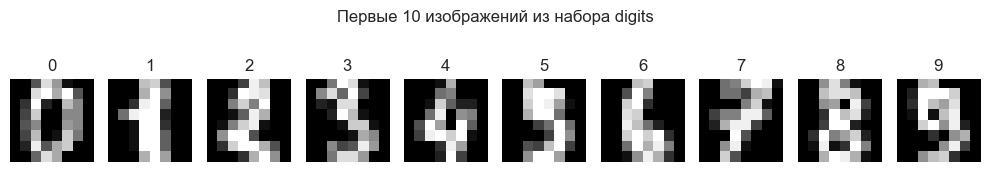

In [32]:
# Загрузка и разделение данных
digits = load_digits()
X, y = digits.data, digits.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits

# Загрузка данных
digits = load_digits()
images, labels = digits.images, digits.target

# Вывод первых 10 изображений
plt.figure(figsize=(10, 2))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(images[i], cmap='gray')
    plt.title(labels[i])
    plt.axis('off')
plt.suptitle("Первые 10 изображений из набора digits")
plt.tight_layout()
plt.show()

In [33]:
# Классификаторы
models = {
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "CatBoost": CatBoostClassifier(verbose=0, random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Extra Trees": ExtraTreesClassifier(random_state=42),
    "QDA": QuadraticDiscriminantAnalysis(),
    "LightGBM": LGBMClassifier(random_state=42),
    "K Neighbors": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42),
    "Dummy": DummyClassifier(strategy='most_frequent'),
    "SVM (Linear)": SVC(kernel='linear', probability=True, random_state=42)
}

In [34]:
# Обучение и сравнение моделей
results = []
for name, model in models.items():
    print(f'Training: {name}')
    if name == 'QDA':
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)
    else:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')
    try:
        roc = roc_auc_score(y_test, y_proba, multi_class='ovo', average='macro')
    except:
        roc = np.nan
    results.append({
        "Model": name,
        "Accuracy": acc,
        "F1 Score": f1,
        "ROC AUC": roc
    })

Training: Gradient Boosting
Training: CatBoost
Training: AdaBoost
Training: Extra Trees
Training: QDA
Training: LightGBM
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000362 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 885
[LightGBM] [Info] Number of data points in the train set: 1437, number of used features: 53
[LightGBM] [Info] Start training from score -2.314486
[LightGBM] [Info] Start training from score -2.286706
[LightGBM] [Info] Start training from score -2.314486
[LightGBM] [Info] Start training from score -2.286706
[LightGBM] [Info] Start training from score -2.293579
[LightGBM] [Info] Start training from score -2.293579
[LightGBM] [Info] Start training from score -2.293579
[LightGBM] [Info] Start training from score -2.307468
[LightGBM] [Info] Start training from score -2.335839
[LightGBM] [Info] Start training from scor

In [35]:
# Таблица результатов
df_results = pd.DataFrame(results)
df_results_sorted = df_results.sort_values(by='F1 Score', ascending=False).reset_index(drop=True)
df_results_sorted

,Model,Accuracy,F1 Score,ROC AUC
0,CatBoost,0.980556,0.980465,0.999684
1,SVM (Linear),0.975000,0.974803,0.999613
2,Extra Trees,0.975000,0.974691,0.999657
3,LightGBM,0.963889,0.963551,0.998366
4,K Neighbors,0.963889,0.963440,0.995022
5,XGBoost,0.961111,0.960598,0.997911
6,Gradient Boosting,0.952778,0.952067,0.998844
7,Decision Tree,0.816667,0.814841,0.897727
8,QDA,0.797222,0.797826,0.963898
9,AdaBoost,0.727778,0.719735,0.956977


In [36]:
# Лучшая модель
best_model_name = df_results_sorted.iloc[0]['Model']
print(f'Лучшая модель по F1 Score: {best_model_name}')

Лучшая модель по F1 Score: CatBoost


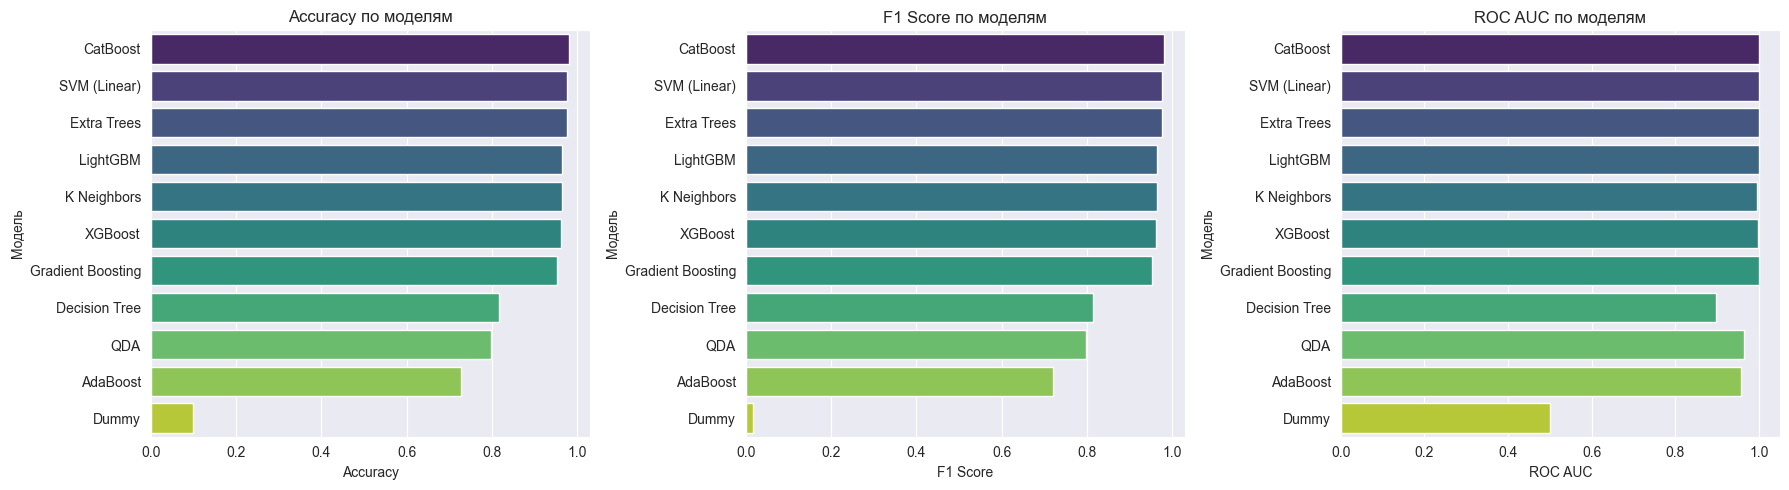

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
# Графики метрик
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = ['Accuracy', 'F1 Score', 'ROC AUC']
for ax, metric in zip(axes, metrics):
    sns.barplot(data=df_results_sorted, x=metric, y='Model', ax=ax, palette='viridis')
    ax.set_title(f'{metric} по моделям')
    ax.set_xlabel(metric)
    ax.set_ylabel('Модель')
plt.tight_layout()
plt.show()